# DBSCAN - TSI

Notebook independiente para detectar estructuras densas y puntos aislados con DBSCAN, eligiendo automáticamente la fuente limpia con mejor cobertura y ajustando los parámetros para evitar una evaluación plana o poco confiable. La meta es obtener una segmentación interpretable y una versión filtrada del dataset lista para comparación con Isolation Forest y LOF.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [2]:
PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
     if (candidate / 'data' / '02_clean').exists()),
    Path.cwd()
)

feature_candidates = [
    'velocidad',
    'densidad',
    'detenciones',
    'velocity_kmh',
    'density_veh_km',
    'flow_veh_h',
    'wait_time_sec',
    'stops_count',
    'confidence',
    'avg_confidence',
    'speed_congestion',
    'tsi',
    'velocidad_norm',
    'densidad_norm',
    'detenciones_norm',
]

source_candidates = [
    PROJECT_ROOT / 'data' / '02_clean' / 'traffic_enriched.csv',
    PROJECT_ROOT / 'data' / '02_clean' / 'historical_consolidated.csv',
    PROJECT_ROOT / 'data' / '02_clean' / 'traffic_data.csv',
]

candidate_reports = []
candidate_payloads = []

for candidate_path in source_candidates:
    if not candidate_path.exists():
        continue

    candidate_df = pd.read_csv(candidate_path)
    candidate_df.columns = (
        candidate_df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'[^0-9a-z]+', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )

    if 'avenida' not in candidate_df.columns and 'road' in candidate_df.columns:
        candidate_df = candidate_df.rename(columns={'road': 'avenida'})

    if 'hora' not in candidate_df.columns and 'hour' in candidate_df.columns:
        candidate_df['hora'] = candidate_df['hour']

    if 'timestamp' in candidate_df.columns:
        candidate_df['timestamp'] = pd.to_datetime(candidate_df['timestamp'], errors='coerce')

    available_features = [column for column in feature_candidates if column in candidate_df.columns]
    if len(available_features) < 3:
        continue

    numeric_frame = candidate_df[available_features].apply(pd.to_numeric, errors='coerce')
    numeric_frame = numeric_frame.loc[:, numeric_frame.nunique(dropna=True) > 1]
    if numeric_frame.shape[1] == 0:
        continue

    min_complete_features = max(3, min(5, numeric_frame.shape[1]))
    usable_mask = numeric_frame.notna().sum(axis=1) >= min_complete_features
    usable_rows = int(usable_mask.sum())
    completeness_ratio = float(numeric_frame.notna().mean().mean())

    candidate_reports.append({
        'source': candidate_path.name,
        'rows': len(candidate_df),
        'features': len(available_features),
        'usable_rows': usable_rows,
        'completeness_ratio': round(completeness_ratio, 4),
        'min_complete_features': min_complete_features,
    })
    candidate_payloads.append({
        'source_path': candidate_path,
        'dataframe': candidate_df,
        'analysis_frame': numeric_frame,
        'available_features': available_features,
        'min_complete_features': min_complete_features,
        'usable_rows': usable_rows,
        'completeness_ratio': completeness_ratio,
        'rows': len(candidate_df),
    })

if not candidate_payloads:
    raise FileNotFoundError('No se encontró un dataset limpio utilizable en data/02_clean')

diagnostics_df = pd.DataFrame(candidate_reports).sort_values(
    by=['completeness_ratio', 'usable_rows', 'rows'],
    ascending=[False, False, False],
).reset_index(drop=True)

best_payload = max(
    candidate_payloads,
    key=lambda item: (item['completeness_ratio'], item['usable_rows'], item['rows']),
)

source_path = best_payload['source_path']
df = best_payload['dataframe'].copy()
analysis_frame = best_payload['analysis_frame'].copy()
available_features = best_payload['available_features']
min_complete_features = best_payload['min_complete_features']

row_mask = analysis_frame.notna().sum(axis=1) >= min_complete_features
df = df.loc[row_mask].copy()
analysis_frame = analysis_frame.loc[row_mask].copy()

print('Diagnóstico de fuentes candidatas:')
print(diagnostics_df.to_string(index=False))
print()
print(f'Fuente seleccionada: {source_path.name}')
print(f'Registros usados para DBSCAN: {len(df):,}')
print(f'Variables utilizadas: {", ".join(available_features)}')
print(f'Umbral mínimo de variables completas por fila: {min_complete_features}')
print()
print('Vista previa de datos seleccionados:')
preview_columns = [column for column in ['avenida', 'timestamp'] if column in df.columns] + available_features[:5]
print(df[preview_columns].head(5).to_string(index=False))

Diagnóstico de fuentes candidatas:
                     source  rows  features  usable_rows  completeness_ratio  min_complete_features
       traffic_enriched.csv   288         8          288              1.0000                      5
           traffic_data.csv    18         6            0              1.0000                      3
historical_consolidated.csv  5706        10         5040              0.5666                      5

Fuente seleccionada: traffic_enriched.csv
Registros usados para DBSCAN: 288
Variables utilizadas: velocidad, densidad, detenciones, speed_congestion, tsi, velocidad_norm, densidad_norm, detenciones_norm
Umbral mínimo de variables completas por fila: 5

Vista previa de datos seleccionados:
     avenida           timestamp  velocidad  densidad  detenciones  speed_congestion    tsi
Simulada_ZMG 2026-03-20 00:00:00      56.71      1.32            0          0.261286 0.1323
Simulada_ZMG 2026-03-20 00:05:00      56.18      1.07            0          0.268857 0.071

In [5]:
analysis_frame = analysis_frame.apply(pd.to_numeric, errors='coerce')
analysis_frame = analysis_frame.loc[:, analysis_frame.nunique(dropna=True) > 1]
analysis_frame = analysis_frame.ffill().bfill()
analysis_frame = analysis_frame.fillna(analysis_frame.median(numeric_only=True))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(analysis_frame)

n_samples = X_scaled.shape[0]
target_noise_ratio = 0.10
target_cluster_count = 6
parameter_grid = []

for min_samples in range(4, 13):
    if min_samples >= n_samples:
        continue

    nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
    nearest_neighbors.fit(X_scaled)
    distances, _ = nearest_neighbors.kneighbors(X_scaled)
    k_distances = distances[:, -1]
    k_distance_series = pd.Series(k_distances)

    for quantile in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97]:
        eps = float(k_distance_series.quantile(quantile))
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        noise_mask = labels == -1
        noise_count = int(noise_mask.sum())
        noise_ratio = noise_count / n_samples
        cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
        if cluster_count < 1:
            continue

        cluster_sizes = pd.Series(labels[labels != -1]).value_counts(normalize=True)
        largest_cluster_share = float(cluster_sizes.max()) if not cluster_sizes.empty else 0.0
        balance_score = (
            -(abs(noise_ratio - target_noise_ratio) * 25)
            - (abs(cluster_count - target_cluster_count) * 2.5)
            + largest_cluster_share * 1.0
        )

        parameter_grid.append({
            'min_samples': min_samples,
            'quantile': quantile,
            'eps': eps,
            'noise_count': noise_count,
            'noise_ratio': noise_ratio,
            'cluster_count': cluster_count,
            'largest_cluster_share': largest_cluster_share,
            'balance_score': balance_score,
        })

if not parameter_grid:
    raise ValueError('DBSCAN no encontró combinaciones válidas de parámetros')

parameter_grid_df = pd.DataFrame(parameter_grid).sort_values(
    by=['balance_score', 'cluster_count', 'noise_count'],
    ascending=[False, False, False],
).reset_index(drop=True)

best_params = parameter_grid_df.iloc[0].to_dict()
best_min_samples = int(best_params['min_samples'])
best_eps = float(best_params['eps'])
best_quantile = float(best_params['quantile'])

nearest_neighbors = NearestNeighbors(n_neighbors=best_min_samples)
nearest_neighbors.fit(X_scaled)
distances, _ = nearest_neighbors.kneighbors(X_scaled)
k_distance_series = pd.Series(distances[:, -1])

model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = model.fit_predict(X_scaled)

result_df = df.copy()
result_df['dbscan_cluster'] = labels
result_df['dbscan_is_noise'] = result_df['dbscan_cluster'] == -1
result_df['dbscan_cluster_label'] = result_df['dbscan_cluster'].where(result_df['dbscan_cluster'] != -1, 'noise')

noise_count = int(result_df['dbscan_is_noise'].sum())
retained_count = int((~result_df['dbscan_is_noise']).sum())
retained_pct = retained_count / len(result_df) * 100
noise_pct = noise_count / len(result_df) * 100
cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
cluster_distribution = pd.Series(labels[labels != -1]).value_counts().sort_index()

print('Top 10 combinaciones evaluadas:')
print(parameter_grid_df.head(10).to_string(index=False))
print()
print('Parámetros seleccionados:')
print(f"min_samples={best_min_samples}, eps={best_eps:.4f}, quantile={best_quantile:.2f}")
print()
print(f'Total de registros modelados: {len(result_df):,}')
print(f'Clusters detectados: {cluster_count}')
print(f'Registros retenidos como estructura: {retained_count:,} ({retained_pct:.2f}%)')
print(f'Puntos de ruido detectados: {noise_count:,} ({noise_pct:.2f}%)')
print()
print('Distribución de clusters (sin ruido):')
print(cluster_distribution.to_string())
print()
print('Cuantiles de k-distance para el min_samples elegido:')
print(k_distance_series.quantile([0.0, 0.5, 0.9, 0.95, 0.97, 1.0]).to_string())

Top 10 combinaciones evaluadas:
 min_samples  quantile      eps  noise_count  noise_ratio  cluster_count  largest_cluster_share  balance_score
           9       0.7 0.417083           26     0.090278              6               0.354962       0.111906
           8       0.7 0.387934           33     0.114583              6               0.360784      -0.003799
           7       0.7 0.350463           39     0.135417              6               0.369478      -0.515939
           6       0.8 0.386293           18     0.062500              6               0.344444      -0.593056
          12       0.7 0.502584           13     0.045139              6               0.349091      -1.022437
           9       0.8 0.488362            7     0.024306              6               0.345196      -1.547165
          10       0.8 0.521463            6     0.020833              6               0.347518      -1.631649
          12       0.6 0.458148           30     0.104167              7        

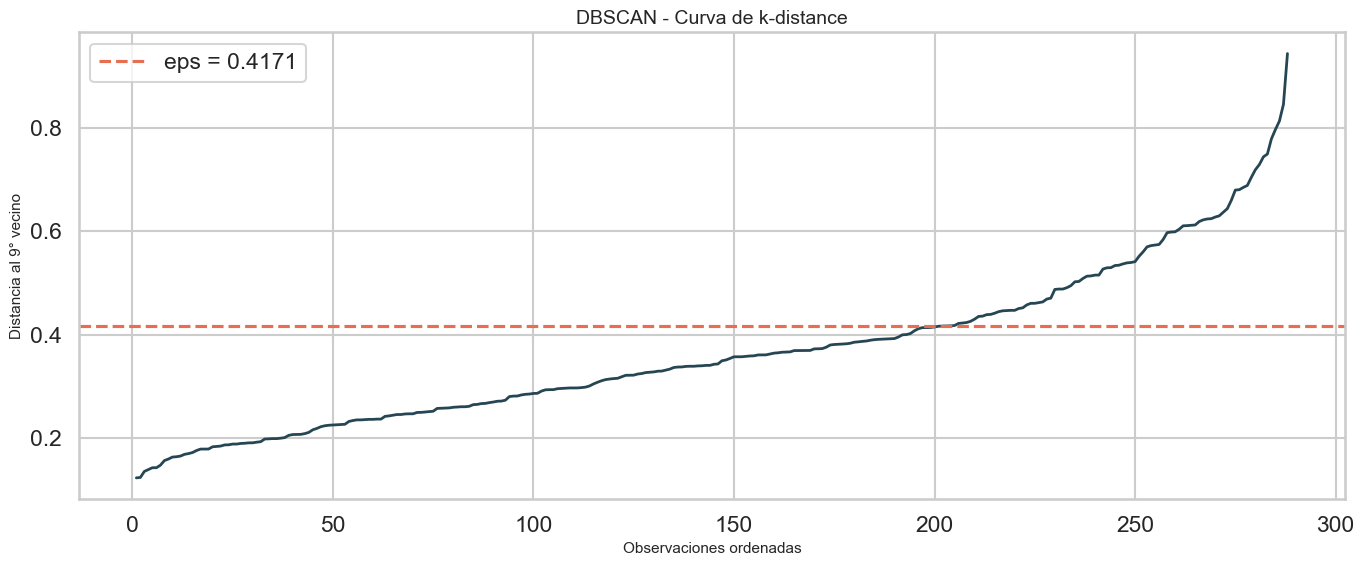

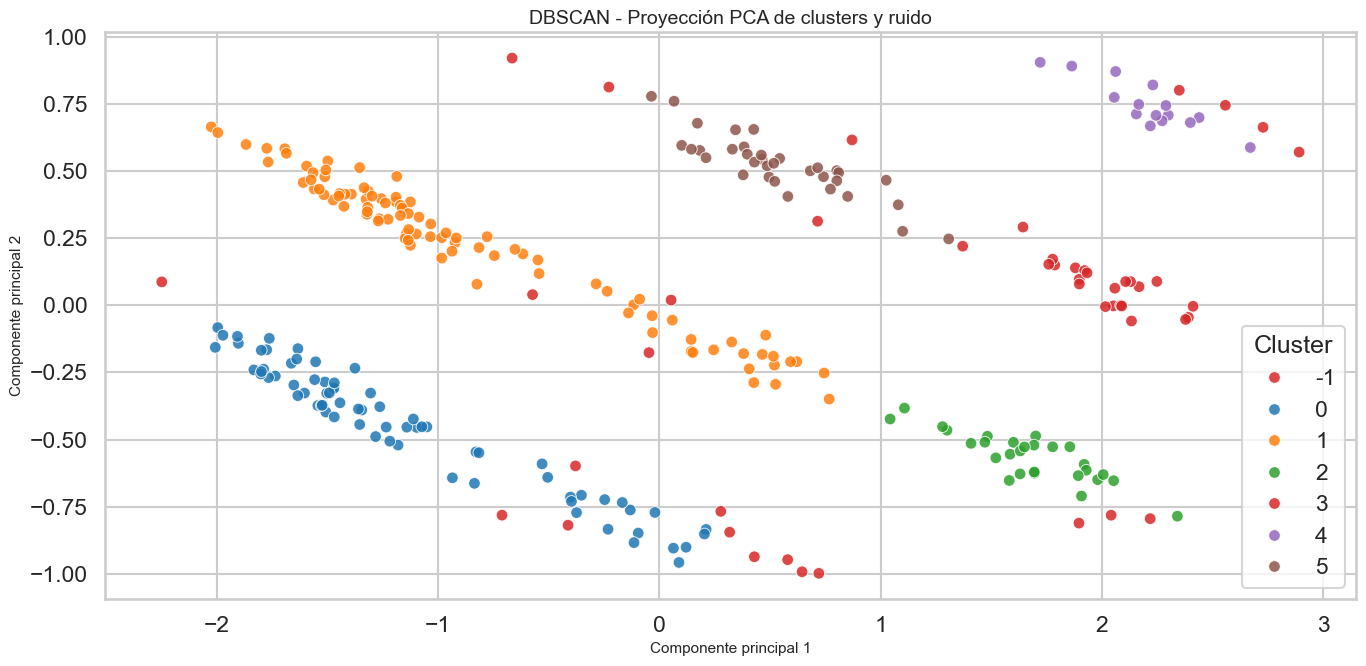

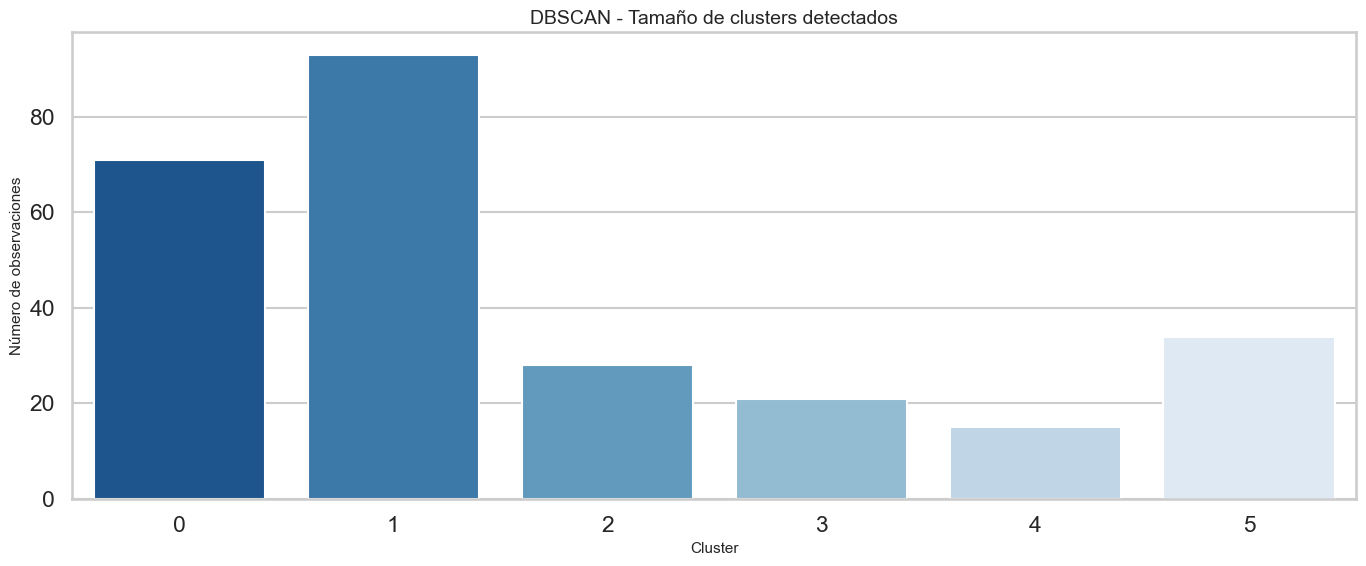

Archivo limpio guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\02_clean\filtered_dbscan.csv
Puntos de ruido guardados en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\dbscan_noise_points.csv
Resumen guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\dbscan_summary.csv
Gráfico PCA guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\dbscan_pca_clusters.png
Gráfico k-distance guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\dbscan_kdistance_curve.png
Gráfico de tamaños de cluster guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\dbscan_cluster_sizes.png


In [6]:
filtered_df = result_df.loc[~result_df['dbscan_is_noise']].copy()
noise_df = result_df.loc[result_df['dbscan_is_noise']].copy()

clean_output_path = PROJECT_ROOT / 'data' / '02_clean' / 'filtered_dbscan.csv'
algorithm_output_dir = PROJECT_ROOT / 'data' / '03_algorithm_output'
algorithm_output_dir.mkdir(parents=True, exist_ok=True)

noise_output_path = algorithm_output_dir / 'dbscan_noise_points.csv'
summary_output_path = algorithm_output_dir / 'dbscan_summary.csv'
pca_plot_path = algorithm_output_dir / 'dbscan_pca_clusters.png'
kdistance_plot_path = algorithm_output_dir / 'dbscan_kdistance_curve.png'
cluster_size_plot_path = algorithm_output_dir / 'dbscan_cluster_sizes.png'

filtered_df.to_csv(clean_output_path, index=False)
noise_df.to_csv(noise_output_path, index=False)

summary_df = pd.DataFrame([
    {'metric': 'total_registros', 'value': len(result_df)},
    {'metric': 'registros_retenidos', 'value': len(filtered_df)},
    {'metric': 'ruido_detectado', 'value': len(noise_df)},
    {'metric': 'porcentaje_retenido', 'value': round(len(filtered_df) / len(result_df) * 100, 2)},
    {'metric': 'porcentaje_ruido', 'value': round(len(noise_df) / len(result_df) * 100, 2)},
    {'metric': 'clusters_detectados', 'value': cluster_count},
    {'metric': 'min_samples', 'value': best_min_samples},
    {'metric': 'eps', 'value': round(best_eps, 6)},
    {'metric': 'quantile_k_distance', 'value': best_quantile},
    {'metric': 'variables_usadas', 'value': ', '.join(available_features)},
])
summary_df.to_csv(summary_output_path, index=False)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    'pca_1': components[:, 0],
    'pca_2': components[:, 1],
    'cluster': result_df['dbscan_cluster'].astype(int).values,
})

cluster_ids = sorted([cluster_id for cluster_id in result_df['dbscan_cluster'].unique() if cluster_id != -1])
palette = sns.color_palette('tab10', n_colors=max(1, len(cluster_ids)))
cluster_palette = {cluster_id: palette[index % len(palette)] for index, cluster_id in enumerate(cluster_ids)}
cluster_palette[-1] = '#d62828'

fig, ax = plt.subplots(figsize=(14, 6))
ordered_k_distance = np.sort(k_distance_series.values)
ax.plot(range(1, len(ordered_k_distance) + 1), ordered_k_distance, color='#264653', linewidth=2)
ax.axhline(best_eps, color='#e76f51', linestyle='--', label=f'eps = {best_eps:.4f}')
ax.set_title('DBSCAN - Curva de k-distance')
ax.set_xlabel('Observaciones ordenadas')
ax.set_ylabel(f'Distancia al {best_min_samples}° vecino')
ax.legend()
plt.tight_layout()
plt.savefig(kdistance_plot_path, dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(
    data=plot_df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette=cluster_palette,
    s=70,
    alpha=0.85,
    ax=ax,
    legend='brief',
)
ax.set_title('DBSCAN - Proyección PCA de clusters y ruido')
ax.set_xlabel('Componente principal 1')
ax.set_ylabel('Componente principal 2')
ax.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.savefig(pca_plot_path, dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
cluster_size_series = result_df.loc[result_df['dbscan_cluster'] != -1, 'dbscan_cluster'].value_counts().sort_index()
sns.barplot(x=cluster_size_series.index.astype(str), y=cluster_size_series.values, palette='Blues_r', ax=ax)
ax.set_title('DBSCAN - Tamaño de clusters detectados')
ax.set_xlabel('Cluster')
ax.set_ylabel('Número de observaciones')
plt.tight_layout()
plt.savefig(cluster_size_plot_path, dpi=160, bbox_inches='tight')
plt.show()

print(f'Archivo limpio guardado en: {clean_output_path}')
print(f'Puntos de ruido guardados en: {noise_output_path}')
print(f'Resumen guardado en: {summary_output_path}')
print(f'Gráfico PCA guardado en: {pca_plot_path}')
print(f'Gráfico k-distance guardado en: {kdistance_plot_path}')
print(f'Gráfico de tamaños de cluster guardado en: {cluster_size_plot_path}')

## Cierre

Este notebook deja una implementación independiente de DBSCAN con selección de fuente por cobertura, búsqueda guiada de parámetros y exportación de resultados limpios. El siguiente paso es comparar DBSCAN contra Isolation Forest y LOF con métricas homogéneas para integrar la métrica final TSI.